In [291]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctr

<TransferFunction>: sys[1242]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  5 s + 33.33
  -----------
      s^2


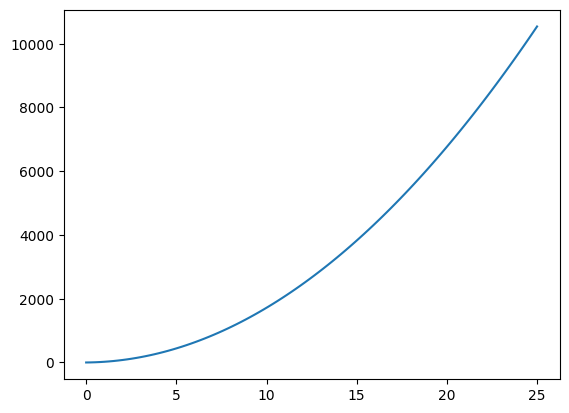

In [292]:
G_s = ctr.tf([5, 33.33], [1, 0, 0])
print(G_s)

t, y = ctr.step_response(G_s)
plt.plot(t, y)
plt.show()

<TransferFunction>: sys[1246]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     5 s + 33.33
  -----------------
  s^2 + 5 s + 33.33

Polos do feedback de G_s(s): [-2.5+5.20384473j -2.5-5.20384473j]


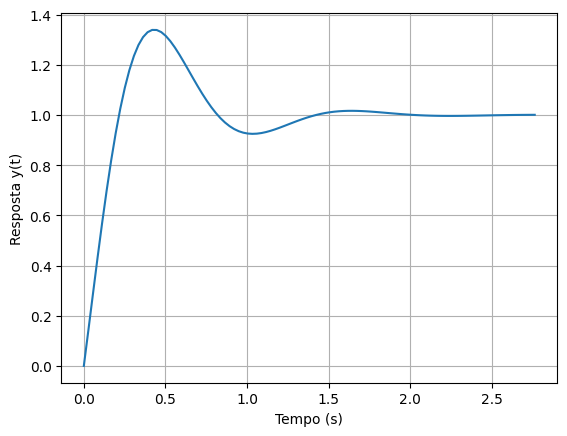

{'RiseTime': 0.16746073403593062,
 'SettlingTime': 1.339685872287445,
 'SettlingMin': 0.9248546901876314,
 'SettlingMax': 1.3389842531007563,
 'Overshoot': 33.89842531007563,
 'Undershoot': 0.0,
 'Peak': 1.3389842531007563,
 'PeakTime': 0.41865183508982656,
 'SteadyStateValue': 1.0}

In [293]:
G_s_feedback = ctr.feedback(G_s, 1)
print(G_s_feedback)

polos_G_s_feedback = ctr.poles(G_s_feedback)  
print(f'\nPolos do feedback de G_s(s): {polos_G_s_feedback}')

t, y = ctr.step_response(G_s_feedback)
plt.plot(t, y)
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta y(t)')
plt.grid()
plt.show()
ctr.step_info(G_s_feedback)

<TransferFunction>: sys[1254]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

       5 s^2 + 33.58 s + 1.667
  ---------------------------------
  s^3 + 10.01 s^2 + 66.94 s + 1.852


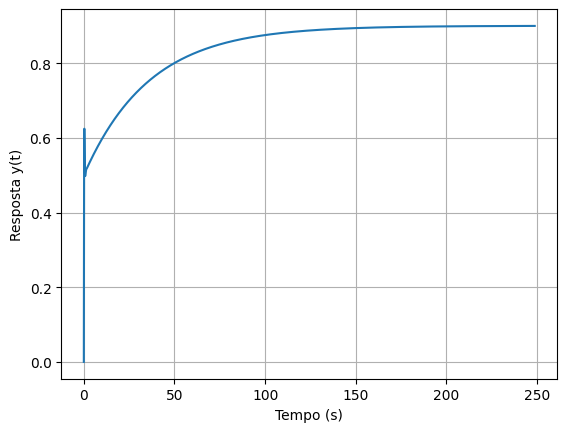

{'RiseTime': 53.676740237264596,
 'SettlingTime': 111.6814474816117,
 'SettlingMin': 0.8100724795050923,
 'SettlingMax': 0.900009000090001,
 'Overshoot': 0.0,
 'Undershoot': 0.0,
 'Peak': 0.8996089948249923,
 'PeakTime': 248.6839892920164,
 'SteadyStateValue': 0.900009000090001}

In [294]:
G_c = ctr.tf([1, 0.05], [1, 0.005555])

G = G_s_feedback * G_c

G_feedback = ctr.feedback(G, 1)
print(G_feedback)

t, y = ctr.step_response(G_feedback)
plt.plot(t, y)
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta y(t)')
plt.grid()
plt.show()
ctr.step_info(G_feedback)